In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mplfinance as mpf
from scipy import stats
from scipy.signal import savgol_filter

## **1. Data Loading and Exploration**

In [2]:
df = pd.read_csv('Apple Stock Prices (1981 to 2023).csv')

In [3]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,02/01/1981,0.154018,0.155134,0.154018,0.154018,0.119849,21660800
1,05/01/1981,0.151228,0.151228,0.150670,0.150670,0.117244,35728000
2,06/01/1981,0.144531,0.144531,0.143973,0.143973,0.112032,45158400
3,07/01/1981,0.138393,0.138393,0.137835,0.137835,0.107256,55686400
4,08/01/1981,0.135603,0.135603,0.135045,0.135045,0.105085,39827200


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10608 entries, 0 to 10607
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10608 non-null  object 
 1   Open       10608 non-null  float64
 2   High       10608 non-null  float64
 3   Low        10608 non-null  float64
 4   Close      10608 non-null  float64
 5   Adj Close  10608 non-null  float64
 6   Volume     10608 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 580.3+ KB


Le jeu de donnée recuilli comporte 10608 échantillons et 7 variables dont :
* Date (objet for the moment): Represents the date of the stock price.
* Open (float64): Represents the opening stock price on that date.
* High float64: Represents the highest stock price on that date.
* Low (float64): Represents the lowest stock price on that date.
* Close (float64): Represents the closing stock price on that date.
* Adj close (float64): Represents the adjusted closing stock price on that date (taking into account corporate actions such as splits).
* Volume (int): Represents the number of shares traded on that date.

In [5]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

On remarque qu'il n'y pas de valeurs manquantes

In [6]:
df.duplicated().sum()

np.int64(0)

Il n'y pas aussi de valeur dupliqué

In [7]:
df['Date'] = pd.to_datetime(df['Date'],dayfirst=True)

Ici, vu que la variable Date était au format object, on l'avons convertie au format date

In [8]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1981-01-02,0.154018,0.155134,0.154018,0.154018,0.119849,21660800
1,1981-01-05,0.151228,0.151228,0.150670,0.150670,0.117244,35728000
2,1981-01-06,0.144531,0.144531,0.143973,0.143973,0.112032,45158400
3,1981-01-07,0.138393,0.138393,0.137835,0.137835,0.107256,55686400
4,1981-01-08,0.135603,0.135603,0.135045,0.135045,0.105085,39827200


## **2. Data Visualization**

### **2.1 Closing prices and traded volume**

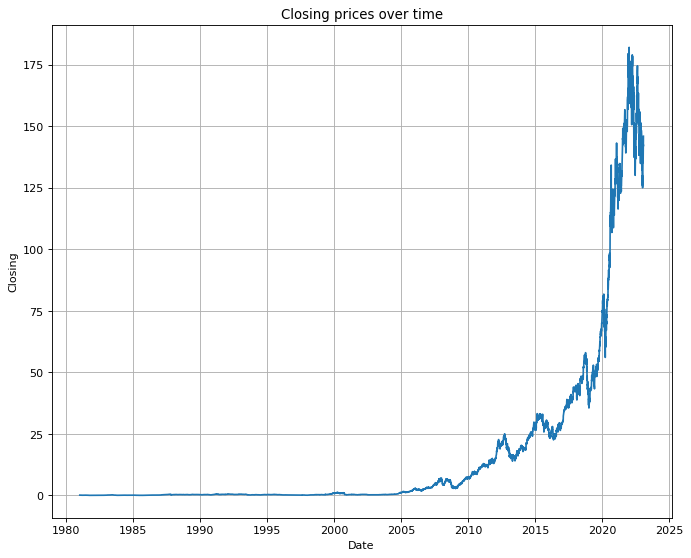

In [9]:
plt.figure(figsize=(10,8),dpi=80)
plt.plot(df['Date'],df['Close'])
plt.title('Closing prices over time')
plt.xlabel('Date')
plt.ylabel('Closing')
plt.grid(True)
plt.show()


On constate que le coût de clôture a commencer à exploser à partir de 2010 et était plûtot stable de 1980 à 2010

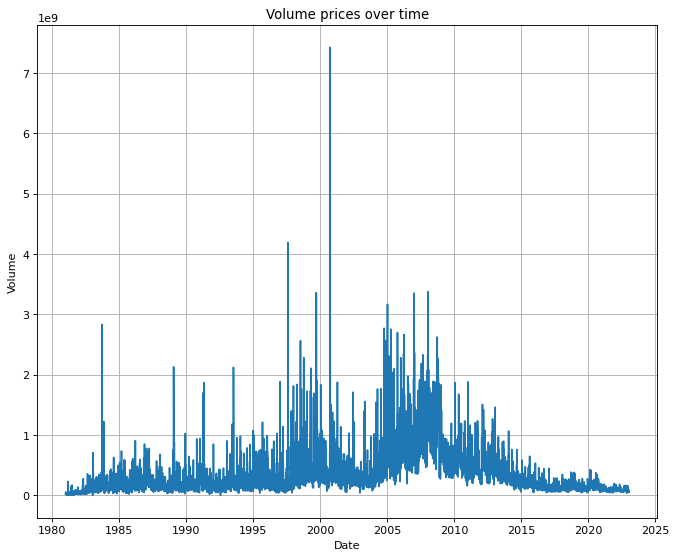

In [10]:
plt.figure(figsize=(10,8),dpi=80)
plt.plot(df['Date'],df['Volume'])
plt.title('Volume prices over time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True)
plt.show()

Le nombre maximal d'échange se situe entre 1995 et 1995. Le volume d'échanges présente une forte volatilité avec plusieurs pics significatifs, indiquant des périodes d'intérêt accru des investisseurs pour l'action Apple.

### **2.2 Candlestick chart**

In [22]:
df.set_index('Date', inplace=True)

/home/cyriac/miniforge3/envs/formation/lib/python3.13/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


<Figure size 1200x800 with 0 Axes>

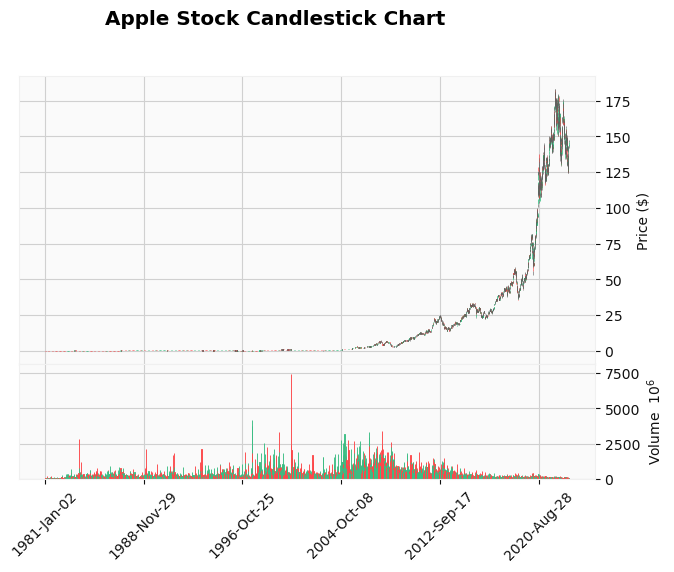

In [27]:
plt.figure(figsize=(12,8), dpi=100)
mpf.plot(
    df,
    type='candle',
    style='yahoo',
    title='Apple Stock Candlestick Chart',
    ylabel='Price ($)',
    volume=True,
)


In [29]:
df[df.index>'2019-12-31']

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-01-02,74.059998,75.150002,73.797501,75.087502,73.561531,135480400
2020-01-03,74.287498,75.144997,74.125000,74.357498,72.846375,146322800
2020-01-06,73.447502,74.989998,73.187500,74.949997,73.426826,118387200
2020-01-07,74.959999,75.224998,74.370003,74.597504,73.081497,108872000
2020-01-08,74.290001,76.110001,74.290001,75.797501,74.257088,132079200
...,...,...,...,...,...,...
2023-01-23,138.119995,143.320007,137.899994,141.110001,141.110001,81760300
2023-01-24,140.309998,143.160004,140.300003,142.529999,142.529999,66435100
2023-01-25,140.889999,142.429993,138.809998,141.860001,141.860001,65799300


Le prix des actions d'apple généralement faible jusqu'à 2019 environ ou il y a une hausse du prix des actions.  
Entre 2020 et 2022, il y a une hausse importantes du prix des actions d'apple, ce qui peut s'expliquer par un écart significatif entre les prix les plus hauts et les prix les plus bas

## **3. Statistical Analysis**

### **3.1 Summary statistics**

In [30]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,10608.000000,10608.000000,10608.000000,10608.000000,10608.000000,1.060800e+04
mean,16.689173,16.879955,16.500822,16.697362,16.027345,3.275098e+08
std,35.450519,35.882848,35.031289,35.473912,35.154878,3.378203e+08
min,0.049665,0.049665,0.049107,0.049107,0.038213,0.000000e+00
25%,0.287946,0.296875,0.282355,0.288923,0.238909,1.213044e+08
50%,0.488839,0.495536,0.480446,0.487701,0.404851,2.145976e+08
75%,16.320893,16.418483,16.151249,16.269554,14.073167,4.066804e+08
max,182.630005,182.940002,179.119995,182.009995,180.959747,7.421641e+09


On observe ici la moyenne , l'écart type pour chaque colonne clé.  
On constate que la moyenne et l'écart type des variables comme Open, High, Low, Close, Adj Close situent à 16 et 35

In [31]:
print(f'Open : {df['Open'].median()}')
print(f'High : {df['High'].median()}')
print(f'Low : {df['Low'].median()}')
print(f'Close : {df['Close'].median()}')
print(f'Adj Close : {df['Adj Close'].median()}')

Open : 0.488839
High : 0.495536
Low : 0.4804465
Close : 0.487701
Adj Close : 0.4048505


Ici aussi on remarque que l'écart type se situe autour de 4 pour les valeurs clés

In [32]:
np.mean(df['Close'])

np.float64(16.69736201451735)

En moyenne, le cours de la clôture à chaque date est d'environ 16,69

## **4. Hypothesis Testing**

### **4.1 T-test pour comparer les cours de clôture moyens** 

Le t-test compare la moyenne de deux groupes

H0 : Le cours moyen des clôtures est pareil chaque années  
H1 : Le cours moyen des clôtures est différente chaque années  
Pour vérifier notre H0 on va prendre 2021 et 2023

In [38]:
close_2021 = df[df.index.year == 2021]['Close']
close_2023 = df[df.index.year == 2023]['Close']

In [39]:
# Performing a one-sample t-test
t_statistic, p_value = stats.ttest_ind(close_2021, close_2023)

# Interpreting the result
alpha = 0.05  # Significance level
print("T-statistic:", t_statistic)
print("P-value:", p_value)
if p_value < alpha:
    print("Rejet de l'hypothèse nulle")
else:
    print("Ne pas rejeter l'hypothèse nulle")

#p-value > 0.05 # hypothèse H0 accepté
#p-value < 0.05 # hypothèse H0 rejeté

T-statistic: 1.7465688955453427
P-value: 0.08185781022292456
Ne pas rejeter l'hypothèse nulle


Ici la p-value > 0.05, donc le coûrs moyen des clôtures est pareil chaque années

### **4.2 Rendement quotidien et test de normalité**

En finance, le rendement quotidien mesure généralement la variation du prix de clôture entre deux jours consécutifs.  
En python, on peut utiliser la bibliothèque pandas avec la fonction **pct_changet()**

In [40]:
df['Daily return'] = df['Close'].pct_change()

In [41]:
df.head()

,Open,High,Low,Close,Adj Close,Volume,Daily return
Date,,,,,,,
1981-01-02,0.154018,0.155134,0.154018,0.154018,0.119849,21660800,NaN
1981-01-05,0.151228,0.151228,0.150670,0.150670,0.117244,35728000,-0.021738
1981-01-06,0.144531,0.144531,0.143973,0.143973,0.112032,45158400,-0.044448
1981-01-07,0.138393,0.138393,0.137835,0.137835,0.107256,55686400,-0.042633
1981-01-08,0.135603,0.135603,0.135045,0.135045,0.105085,39827200,-0.020242


La première valeur est décalée vers le bas, donc il n'y a rien au-dessus de la première ligne, c'est pour que la première valeur du daily return est NaN, donc nous avons préfér la supprimé

In [43]:
df = df.dropna(subset=['Daily return'])

In [44]:
df.head()

,Open,High,Low,Close,Adj Close,Volume,Daily return
Date,,,,,,,
1981-01-05,0.151228,0.151228,0.150670,0.150670,0.117244,35728000,-0.021738
1981-01-06,0.144531,0.144531,0.143973,0.143973,0.112032,45158400,-0.044448
1981-01-07,0.138393,0.138393,0.137835,0.137835,0.107256,55686400,-0.042633
1981-01-08,0.135603,0.135603,0.135045,0.135045,0.105085,39827200,-0.020242
1981-01-09,0.142299,0.142857,0.142299,0.142299,0.110730,21504000,0.053715


In [46]:
#Determinons la moyenne
df['Daily return'].mean()

np.float64(0.0010518641495988169)

<Axes: xlabel='Daily return', ylabel='Count'>

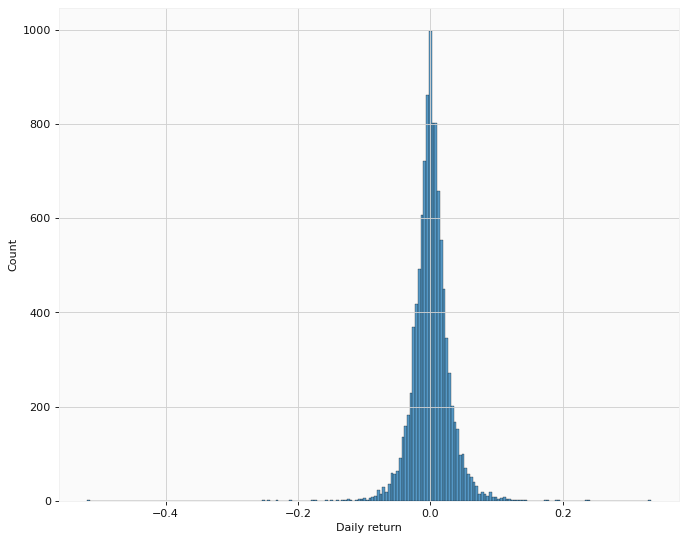

In [45]:
plt.figure(figsize=(10,8), dpi=80)
sns.histplot(df['Daily return'])

Etant donné que la moyenne est de 0.001, on peut voir à travers le graphe que la variable 'Daily return' respecte une loi de normalité.  
Vérifions avec scipy

In [47]:
mu = df['Daily return'].mean()
sigma = df['Daily return'].std()

In [48]:
print(f'Moyenne : {mu}')
print(f'Ecart type : {sigma}')

Moyenne : 0.0010518641495988169
Ecart type : 0.028235401440258164


In [49]:
mu, sigma = round(mu,2), round(sigma,2)

In [50]:
print(f'Moyenne : {mu}')
print(f'Ecart type : {sigma}')

Moyenne : 0.0
Ecart type : 0.03


In [55]:
#Utilisation de la distribution gaussienne pour tester la normalité
gaussian_dist = stats.norm(mu, sigma)
print("PDF at x = 0.5:", gaussian_dist.pdf(0.5))

PDF at x = 0.5: 6.38426299251979e-60


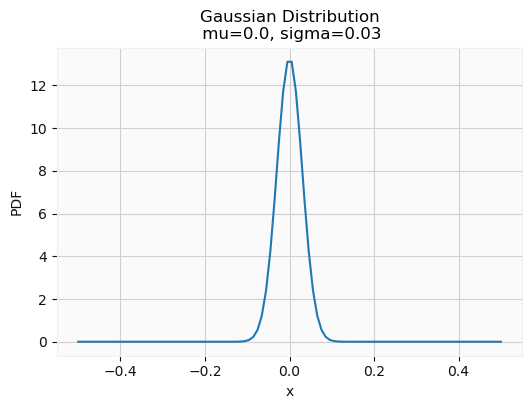

In [54]:
# Plotting Gaussian Distribution
x_gaussian = np.linspace(-0.5, 0.5, 100)
pdf_gaussian = gaussian_dist.pdf(x_gaussian)
plt.figure(figsize=(6, 4))
plt.plot(x_gaussian, pdf_gaussian)
plt.title(f'Gaussian Distribution\n mu={mu}, sigma={sigma}')
plt.xlabel('x')
plt.ylabel('PDF')
plt.show();

On remarque ici aussi que la distribution suit une loi normale

## **5. Advanced Statistical Techniques (Bonus)**

### **5.1 Signal Processing using SciPy**

Utilisations du signal pour extraire les tendances en cours d'action

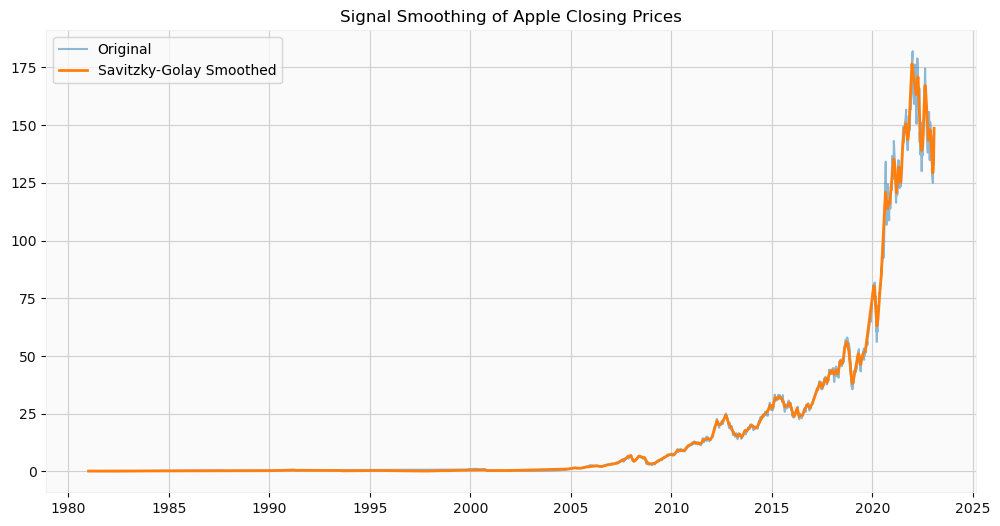

In [62]:
df = df.sort_values('Date')

close = df['Close'].values

smoothed = savgol_filter(
    close,
    window_length=51,
    polyorder=3
)

plt.figure(figsize=(12,6))
plt.plot(df.index, close, alpha=0.5, label='Original')
plt.plot(df.index, smoothed, linewidth=2,
         label='Savitzky-Golay Smoothed')

plt.title("Signal Smoothing of Apple Closing Prices")
plt.legend()
plt.show()

On constate que le signal avec Savitzky-Golay conserve la forme normal du signal mais reduit le bruit et facilite l'identification des tendance à long terme

bruit : variations aléatoires ou irrégulières qui ne reflètent pas la tendance fondamentale du phénomène étudié

### **5.2 Statistical Functions in NumPy**

#### **A. Moyenne mobile avec np.convolve**

In [63]:
window = 30 #Moyenne mobile calculé sur 30 jours
moving_avg = np.convolve(
    df['Close'],
    np.ones(window)/window,
    mode='valid'
)

In [64]:
moving_avg

array([1.34375000e-01, 1.33240300e-01, 1.32496267e-01, ...,
       1.34080000e+02, 1.34062333e+02, 1.34077666e+02], shape=(10578,))

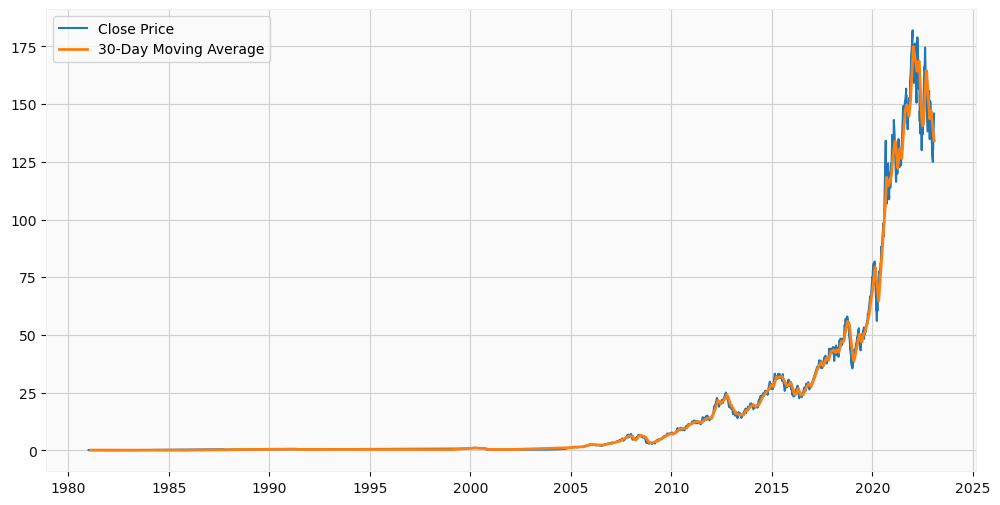

In [69]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df['Close'],
         label='Close Price')

plt.plot(
    df.index[window-1:],
    moving_avg,
    linewidth=2,
    label='30-Day Moving Average'
)

plt.legend()
plt.show()

On remarque ici aussi que la forme normal su signal est conserver

#### **B. Corrélations avec np.corrcoef**

In [72]:
#Prix vs Volume :
df.corr()

,Open,High,Low,Close,Adj Close,Volume,Daily return
Open,1.000000,0.999939,0.999923,0.999838,0.999551,-0.214807,-0.001308
High,0.999939,1.000000,0.999911,0.999924,0.999663,-0.214284,0.000352
Low,0.999923,0.999911,1.000000,0.999927,0.999620,-0.215658,0.000719
Close,0.999838,0.999924,0.999927,1.000000,0.999718,-0.214984,0.002827
Adj Close,0.999551,0.999663,0.999620,0.999718,1.000000,-0.217445,0.002692
Volume,-0.214807,-0.214284,-0.215658,-0.214984,-0.217445,1.000000,0.001475
Daily return,-0.001308,0.000352,0.000719,0.002827,0.002692,0.001475,1.000000


## **6. Summary and Insights**

Notre jeu de données représente le cours des actions d'Apple de 1981 à 2023.  

Il comporte 10607 échantillons et 7 colonnes. Dans un premier temps, nous avons nettoyé notre dataset où nous avons traité les valeurs manquantes, les doublons et la transformation des dates.  

Ensuite, lors de l'analyse, nous avons constaté que c'est à partir de 2020 que le cours des actions d'Apple a explosé sur le marché avec un volume moyen de 327 538 651,89 $. Puis nous avons vérifié que le cours moyen des clôtures était pareil chaque année. Pour cela nous avons pris deux dates de référence : 2021 et 2023, où nous avons affirmé notre hypothèse. De plus, nous avons déterminé le rendement quotidien, où nous avons considéré que ce rendement suit une loi de normalité.

## **7. Reflection**

**Challenges**  
* Dataset très volumineux (plus de 40 ans de données).
* Gestion des dates et des séries temporelles.
* Analyse statistique
* Tests d'hypothèse. 
 
**Solutions**
* Conversion des dates avec pd.to_datetime().
* Utilisation de Pandas pour l'index temporel.
* Utilisation de la moyenne, la médiane, l'écart type
* Utilisation de la t-test pour pour comparer les cours de clôture moyens sur différentes années (2021 et 2023) et teste de normalité